<u><h1>World happiness Index Report</h1></u>

<h4>1) Import Libraries</h4>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

<h4>2) Read The File</h4>

In [2]:
df = pd.read_csv("World Happiness Report.csv")
print("read file successfully")

read file successfully


<h4>3) Clean column names</h4>

In [3]:
df.columns = [col.strip() for col in df.columns]
print(df.columns)

Index(['Country Name', 'Regional Indicator', 'Year', 'Life Ladder',
       'Log GDP Per Capita', 'Social Support',
       'Healthy Life Expectancy At Birth', 'Freedom To Make Life Choices',
       'Generosity', 'Perceptions Of Corruption', 'Positive Affect',
       'Negative Affect', 'Confidence In National Government'],
      dtype='object')


<h4>4) print initial output </h4>

In [4]:
print(df.head())

  Country Name Regional Indicator  Year  Life Ladder  Log GDP Per Capita  \
0  Afghanistan         South Asia  2008     3.723590            7.350416   
1  Afghanistan         South Asia  2009     4.401778            7.508646   
2  Afghanistan         South Asia  2010     4.758381            7.613900   
3  Afghanistan         South Asia  2011     3.831719            7.581259   
4  Afghanistan         South Asia  2012     3.782938            7.660506   

   Social Support  Healthy Life Expectancy At Birth  \
0        0.450662                         50.500000   
1        0.552308                         50.799999   
2        0.539075                         51.099998   
3        0.521104                         51.400002   
4        0.520637                         51.700001   

   Freedom To Make Life Choices  Generosity  Perceptions Of Corruption  \
0                      0.718114    0.167652                   0.881686   
1                      0.678896    0.190809                   0.

In [5]:
print(df.columns.tolist())

['Country Name', 'Regional Indicator', 'Year', 'Life Ladder', 'Log GDP Per Capita', 'Social Support', 'Healthy Life Expectancy At Birth', 'Freedom To Make Life Choices', 'Generosity', 'Perceptions Of Corruption', 'Positive Affect', 'Negative Affect', 'Confidence In National Government']


<h4>5) Filter data for India and Finland</h4>

In [6]:
df_india = df[df['Country Name'] == 'India']
print(df_india)

    Country Name Regional Indicator  Year  Life Ladder  Log GDP Per Capita  \
831        India         South Asia  2006     5.348259            8.141137   
832        India         South Asia  2007     5.026793            8.200289   
833        India         South Asia  2008     5.145833            8.216465   
834        India         South Asia  2009     4.521518            8.278234   
835        India         South Asia  2010     4.989277            8.346016   
836        India         South Asia  2011     4.634871            8.383487   
837        India         South Asia  2012     4.720147            8.423292   
838        India         South Asia  2013     4.427789            8.472221   
839        India         South Asia  2014     4.424379            8.531302   
840        India         South Asia  2015     4.342079            8.596351   
841        India         South Asia  2016     4.179177            8.663832   
842        India         South Asia  2017     4.046111          

In [7]:
df_finland = df[df['Country Name'] == 'Finland']
print(df_finland)

    Country Name Regional Indicator  Year  Life Ladder  Log GDP Per Capita  \
623      Finland     Western Europe  2006     7.672449           10.745317   
624      Finland     Western Europe  2008     7.670627           10.795855   
625      Finland     Western Europe  2010     7.393264           10.733668   
626      Finland     Western Europe  2011     7.354225           10.754190   
627      Finland     Western Europe  2012     7.420209           10.735358   
628      Finland     Western Europe  2013     7.444636           10.721693   
629      Finland     Western Europe  2014     7.384571           10.713902   
630      Finland     Western Europe  2015     7.447926           10.716029   
631      Finland     Western Europe  2016     7.659843           10.740882   
632      Finland     Western Europe  2017     7.788252           10.769960   
633      Finland     Western Europe  2018     7.858107           10.779966   
634      Finland     Western Europe  2019     7.780348          

<h4>6) World average for Life Ladder by Year</h4>

In [8]:
world_avg = df.groupby('Year')['Life Ladder'].mean().reset_index()
print(world_avg)

    Year  Life Ladder
0   2005     6.446164
1   2006     5.196935
2   2007     5.418291
3   2008     5.418554
4   2009     5.457640
5   2010     5.496782
6   2011     5.424088
7   2012     5.443612
8   2013     5.393302
9   2014     5.386267
10  2015     5.400948
11  2016     5.396381
12  2017     5.460421
13  2018     5.498683
14  2019     5.570995
15  2020     5.727539
16  2021     5.636193
17  2022     5.585126


<h4>7) Calculate averages per year for India and Finland</h4>

In [9]:
india_avg = df_india[['Year', 'Life Ladder']].groupby('Year').mean().reset_index()
print(india_avg)

    Year  Life Ladder
0   2006     5.348259
1   2007     5.026793
2   2008     5.145833
3   2009     4.521518
4   2010     4.989277
5   2011     4.634871
6   2012     4.720147
7   2013     4.427789
8   2014     4.424379
9   2015     4.342079
10  2016     4.179177
11  2017     4.046111
12  2018     3.818069
13  2019     3.248770
14  2020     4.223866
15  2021     3.558254
16  2022     3.929816


In [10]:
finland_avg = df_finland[['Year', 'Life Ladder']].groupby('Year').mean().reset_index()
print(finland_avg)

    Year  Life Ladder
0   2006     7.672449
1   2008     7.670627
2   2010     7.393264
3   2011     7.354225
4   2012     7.420209
5   2013     7.444636
6   2014     7.384571
7   2015     7.447926
8   2016     7.659843
9   2017     7.788252
10  2018     7.858107
11  2019     7.780348
12  2020     7.889350
13  2021     7.794378
14  2022     7.728998


<h3>8) Charts</h3>

<h4>---------- A) Bar Charts: World Average vs India vs Finland ---------- </h4>

In [11]:
#Merge these datasets

In [12]:
merged_bar = pd.merge(world_avg, india_avg, on='Year', how='outer', suffixes=('_world', '_india'))
merged_bar = pd.merge(merged_bar, finland_avg, on='Year', how='outer')
merged_bar.rename(columns={'Life Ladder': 'Life Ladder_finland'}, inplace=True)
merged_bar = merged_bar.sort_values('Year')

<h4>Life Ladder: World Average vs India vs Finland</h4>

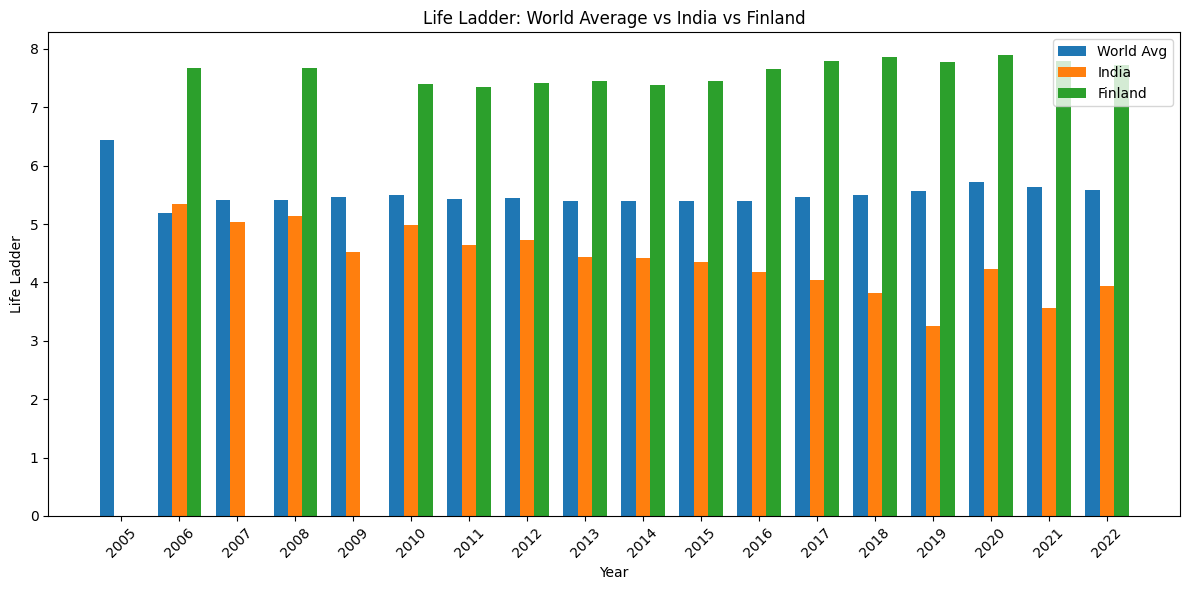

In [13]:
# Plot grouped bar chart
years = merged_bar['Year'].astype(str)
x_val = np.arange(len(years))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x_val - width, merged_bar['Life Ladder_world'], width, label='World Avg')
ax.bar(x_val, merged_bar['Life Ladder_india'], width, label='India')
ax.bar(x_val + width, merged_bar['Life Ladder_finland'], width, label='Finland')
ax.set_xlabel('Year')
ax.set_ylabel('Life Ladder')
ax.set_title('Life Ladder: World Average vs India vs Finland')
ax.set_xticks(x_val)
ax.set_xticklabels(years, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

<h4>---------- B) Line Graphs ---------- </h4>

<h5>plot line graphs for India,Finland and World Average Ladder</h5>

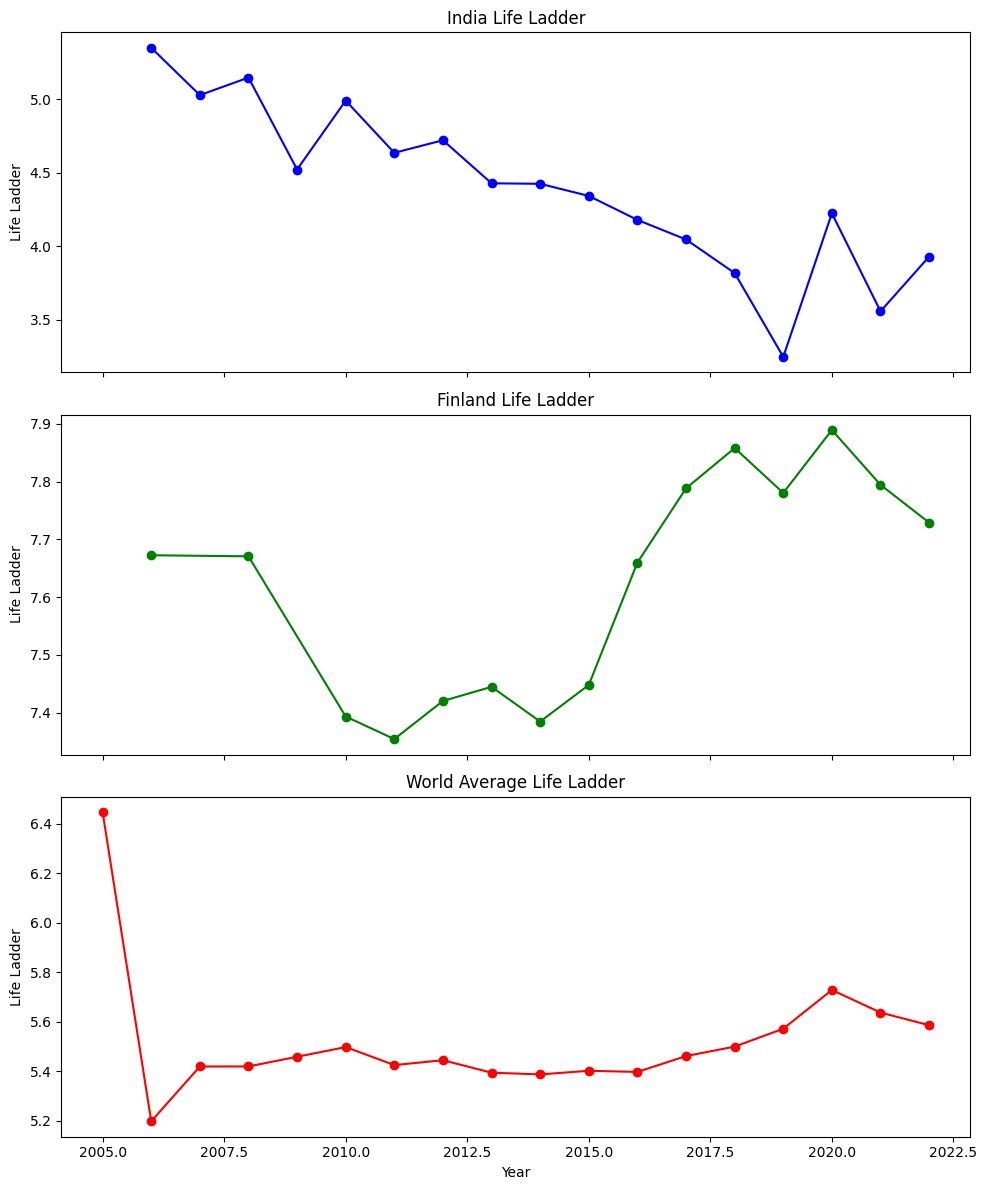

In [14]:
# Plot line graphs for India, Finland and World average on separate subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# India line plot
axs[0].plot(india_avg['Year'], india_avg['Life Ladder'], marker='o', color='blue')
axs[0].set_title('India Life Ladder')
axs[0].set_ylabel('Life Ladder')

# Finland line plot
axs[1].plot(finland_avg['Year'], finland_avg['Life Ladder'], marker='o', color='green')
axs[1].set_title('Finland Life Ladder')
axs[1].set_ylabel('Life Ladder')

# World average line plot
axs[2].plot(world_avg['Year'], world_avg['Life Ladder'], marker='o', color='red')
axs[2].set_title('World Average Life Ladder')
axs[2].set_ylabel('Life Ladder')
axs[2].set_xlabel('Year')

plt.tight_layout()
plt.show()

<h4> ---------- C) Scatter Plots for India ----------</h4>

<h5>1)India: GDP vs Life Ladder<h/5>
<h5>2)India: Healthy Life Expectancy vs Life Ladder</h5>

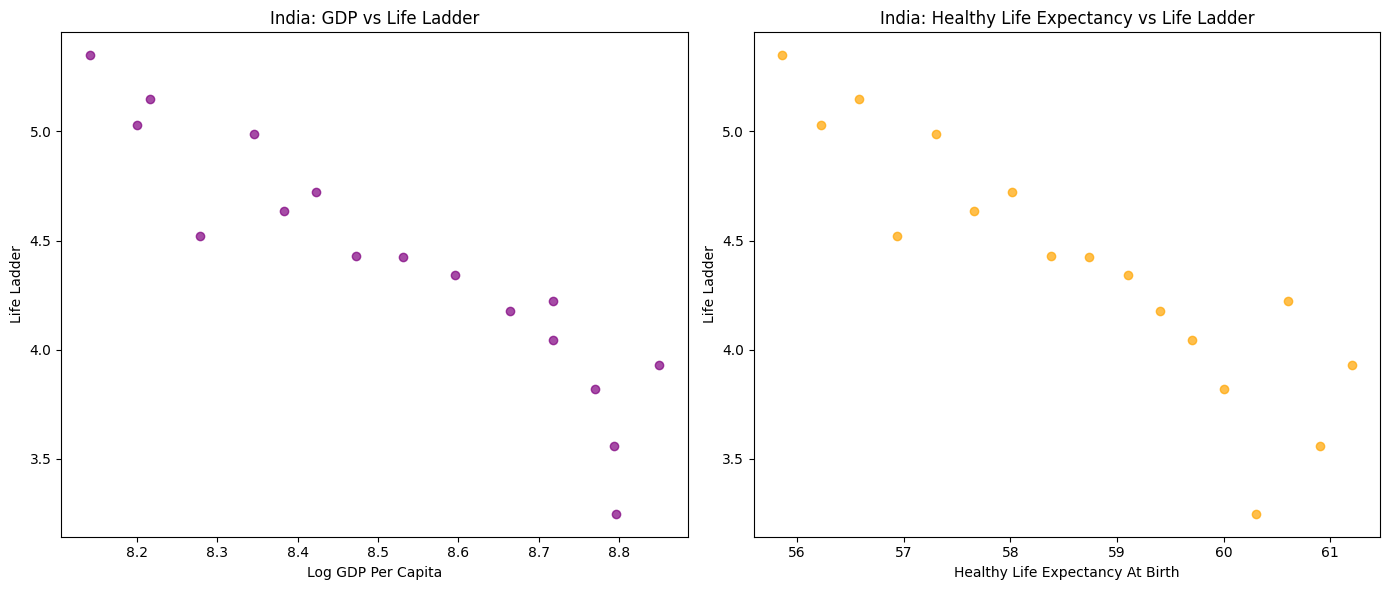

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

axs[0].scatter(df_india['Log GDP Per Capita'], df_india['Life Ladder'], alpha=0.7, color='purple')
axs[0].set_xlabel('Log GDP Per Capita')
axs[0].set_ylabel('Life Ladder')
axs[0].set_title('India: GDP vs Life Ladder')

axs[1].scatter(df_india['Healthy Life Expectancy At Birth'], df_india['Life Ladder'], alpha=0.7, color='orange')
axs[1].set_xlabel('Healthy Life Expectancy At Birth')
axs[1].set_ylabel('Life Ladder')
axs[1].set_title('India: Healthy Life Expectancy vs Life Ladder')

plt.tight_layout()
plt.show()

<h4>---------- D) Additional Scatter Plots ----------</h4>

In [16]:
# ---------- D) Additional Scatter Plots ----------
def scatter_plot(x, y, xlabel, ylabel, title, color='blue'):
    plt.figure(figsize=(8,6))
    plt.scatter(x, y, color=color, alpha=0.7)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

<h4> India: Freedom To Make Life Choices vs Life Ladder </h4>

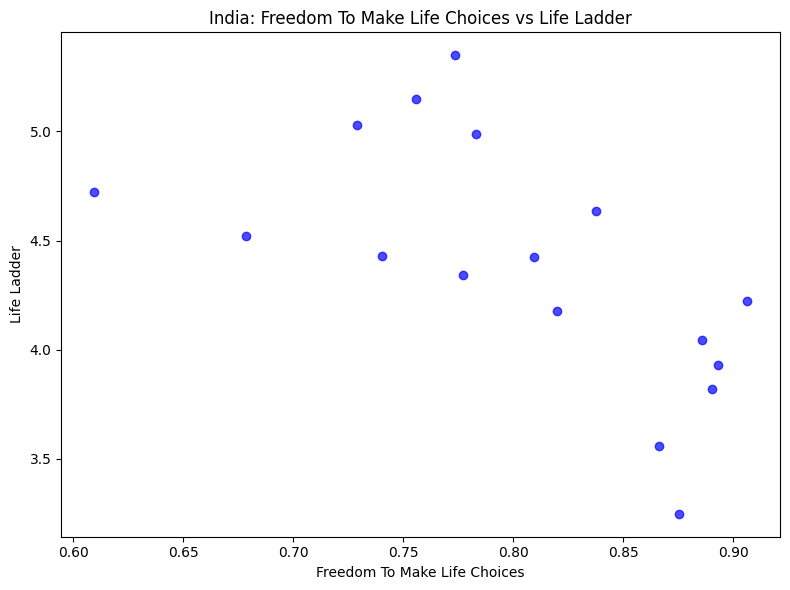

In [17]:
# India
scatter_plot(df_india['Freedom To Make Life Choices'], df_india['Life Ladder'],
             'Freedom To Make Life Choices', 'Life Ladder', 'India: Freedom To Make Life Choices vs Life Ladder')


<h4>Finland: Log GDP Per Capita vs Life Ladder</h4>

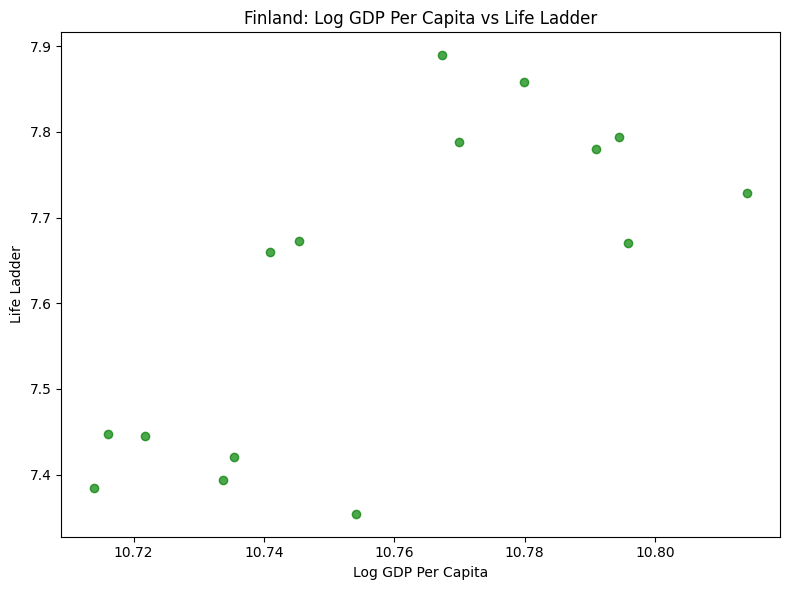

In [18]:
# Finland
scatter_plot(df_finland['Log GDP Per Capita'], df_finland['Life Ladder'],
             'Log GDP Per Capita', 'Life Ladder', 'Finland: Log GDP Per Capita vs Life Ladder', color='green')

<h4>Finland: Healthy Life Expectancy At Birth vs Life Ladder</h4>

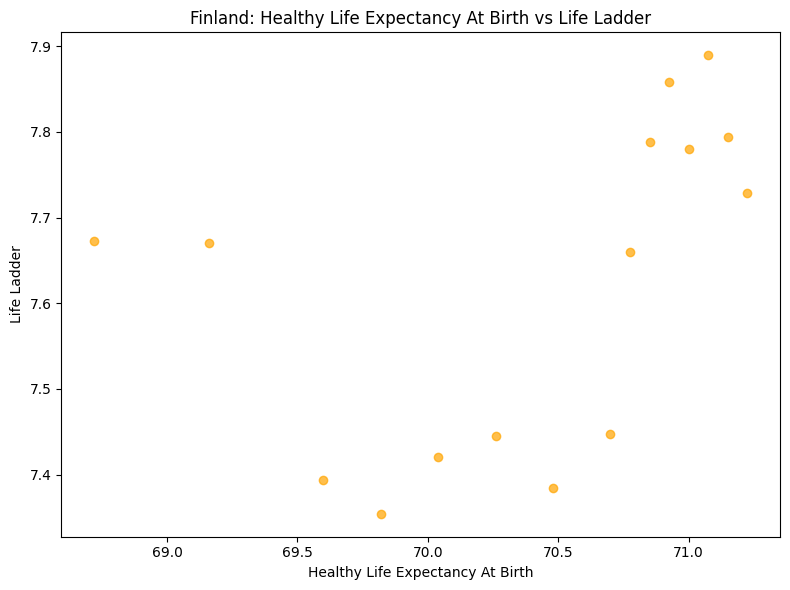

In [19]:
scatter_plot(df_finland['Healthy Life Expectancy At Birth'], df_finland['Life Ladder'],
             'Healthy Life Expectancy At Birth', 'Life Ladder', 'Finland: Healthy Life Expectancy At Birth vs Life Ladder', color='orange')

<h4>Finland: Freedom To Make Life Choices vs Life Ladder</h4>

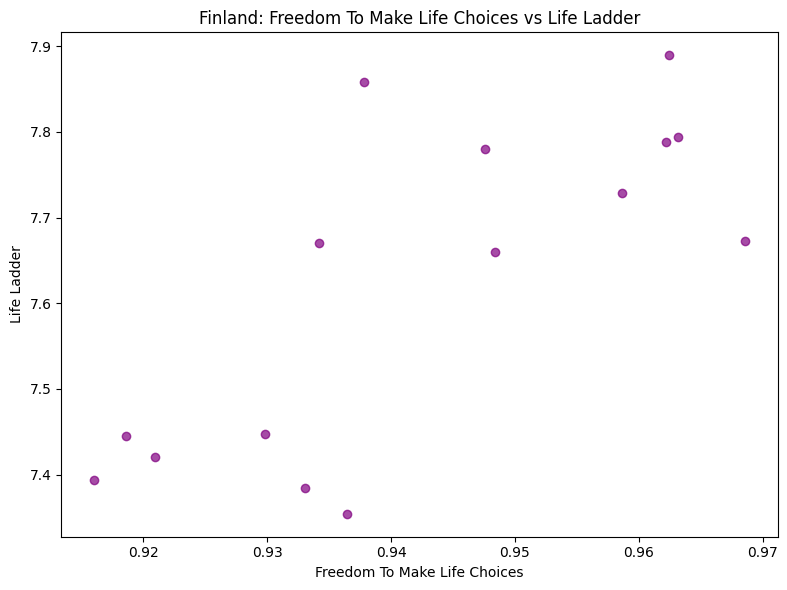

In [20]:
scatter_plot(df_finland['Freedom To Make Life Choices'], df_finland['Life Ladder'],
             'Freedom To Make Life Choices', 'Life Ladder', 'Finland: Freedom To Make Life Choices vs Life Ladder', color='purple')

<h4>World: Log GDP Per Capita vs Life Ladder</h4>

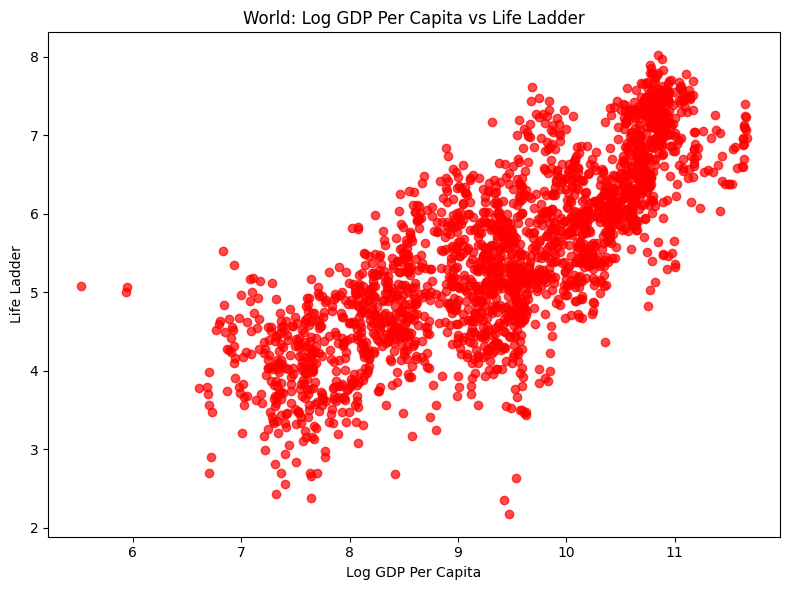

In [21]:
# World
scatter_plot(df['Log GDP Per Capita'], df['Life Ladder'],
             'Log GDP Per Capita', 'Life Ladder', 'World: Log GDP Per Capita vs Life Ladder', color='red')


<h4>World: Healthy Life Expectancy At Birth vs Life Ladder</h4>

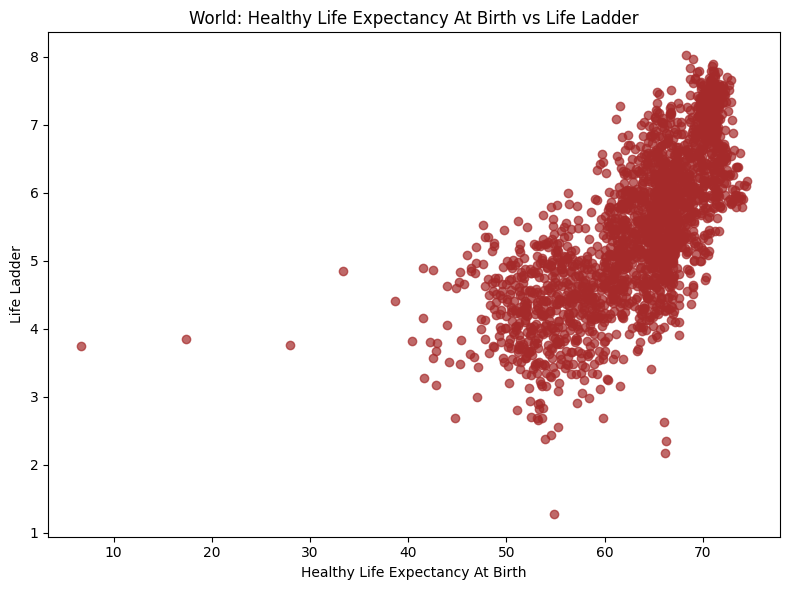

In [22]:
scatter_plot(df['Healthy Life Expectancy At Birth'], df['Life Ladder'],
             'Healthy Life Expectancy At Birth', 'Life Ladder', 'World: Healthy Life Expectancy At Birth vs Life Ladder', color='brown')


<h4>World: Freedom To Make Life Choices vs Life Ladder</h4>

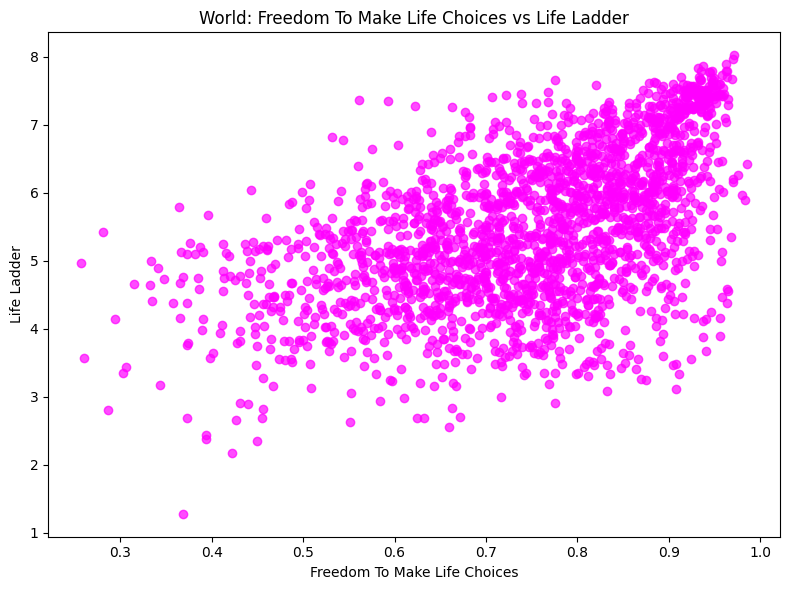

In [23]:
scatter_plot(df['Freedom To Make Life Choices'], df['Life Ladder'],
             'Freedom To Make Life Choices', 'Life Ladder', 'World: Freedom To Make Life Choices vs Life Ladder', color='magenta')


<h4>---------- E) Pie Chart Contributions ----------</h4>

In [24]:
contrib_cols_old = ['Log GDP Per Capita', 'Social Support', 'Healthy Life Expectancy At Birth',
                    'Freedom To Make Life Choices', 'Generosity', 'Perceptions Of Corruption']

contrib_cols_new = ['GDP per Capita', 'Social Support', 'Health', 'Freedom', 'Generosity', 'Trust in Government']

def plot_pie_chart(data_row, title):
    values = abs(data_row[contrib_cols_old].values.astype(float))
    labels = contrib_cols_new
    total = values.sum()

    if total == 0:
        percents = values
    else:
        percents = values / total
        # Sort values
    sorted_indices = np.argsort(percents)[::-1]
    percents = percents[sorted_indices]
    values = values[sorted_indices]
    labels = [labels[i] for i in sorted_indices]

    explode = [0.05] * len(labels)

    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, _ = ax.pie(
        percents,
        labels=None,
        startangle=90,
        explode=explode,
        wedgeprops=dict(width=0.5)
    )
     # Custom legend with percentages
    legend_labels = [f"{label}: {percent * 100:.1f}%" for label, percent in zip(labels, percents)]
    ax.legend(wedges, legend_labels, title="Contributing Factors", loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set_title(title, pad=20, size=12, weight='bold')
    plt.tight_layout()
    plt.show()

In [25]:
# Pie charts for specific years
years = [2019, 2020, 2021, 2022]

<h5>India</h5>

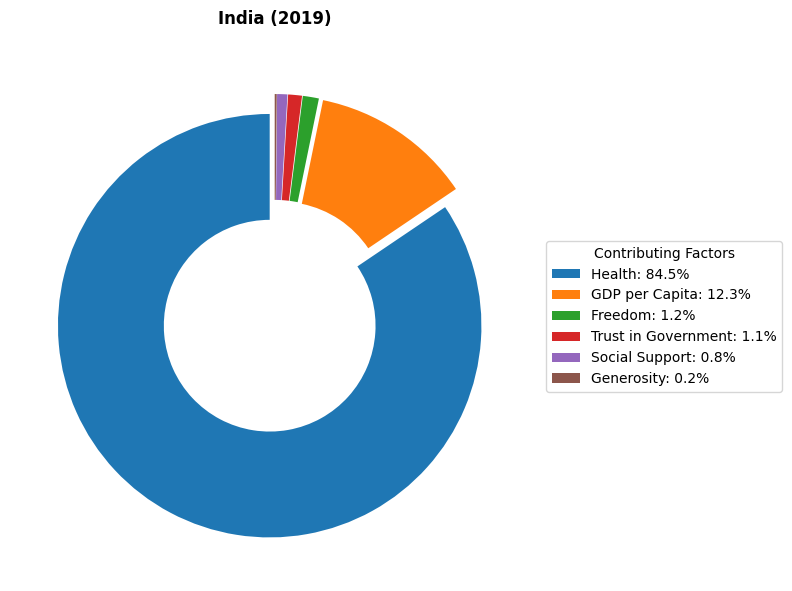

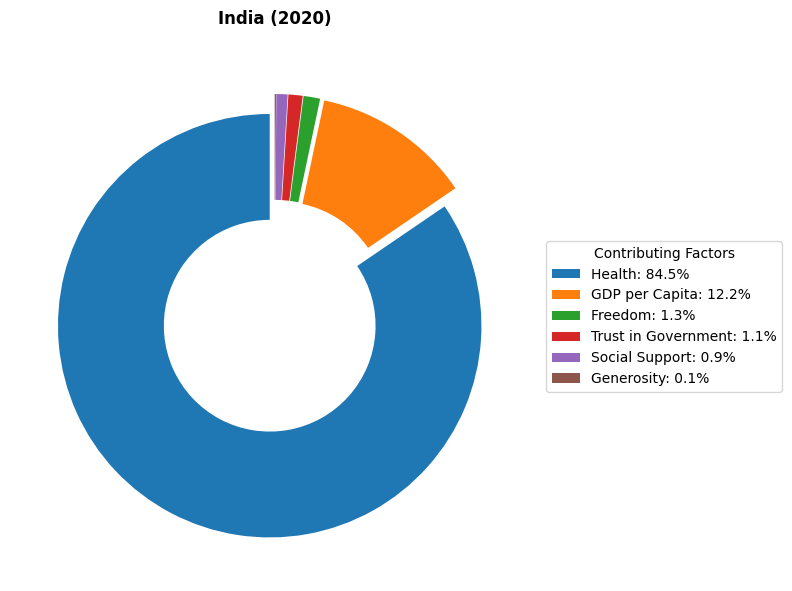

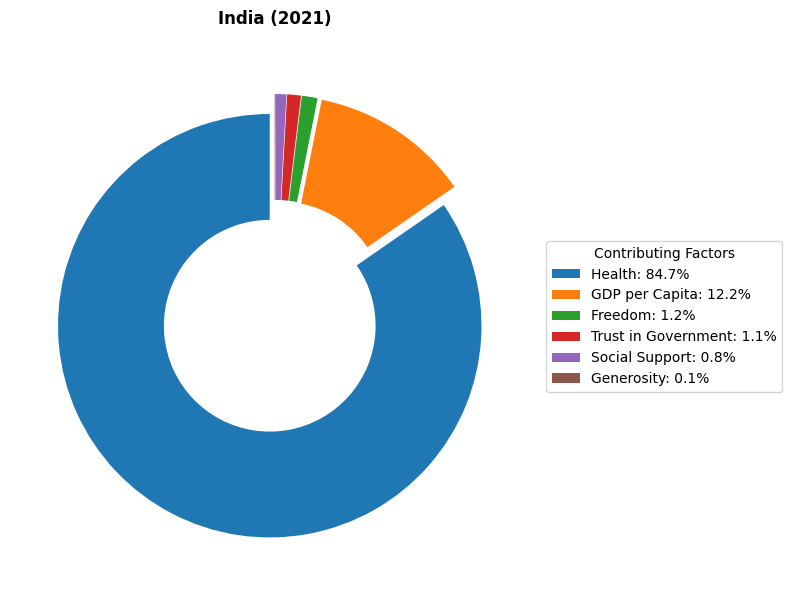

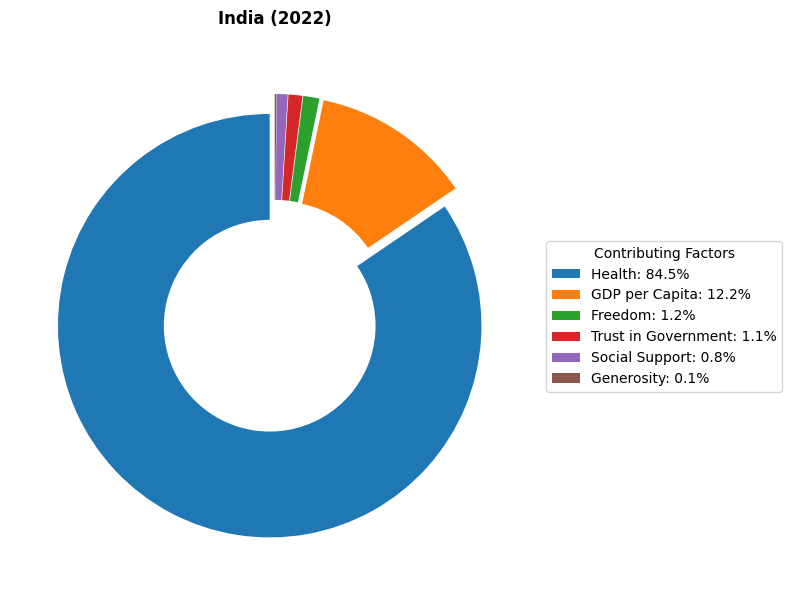

In [26]:
# India
for year in years:
    row = df[(df['Country Name'] == 'India') & (df['Year'] == year)]
    if not row.empty:
        plot_pie_chart(row.iloc[0], f'India ({year})')

<h5>Finland</h5>

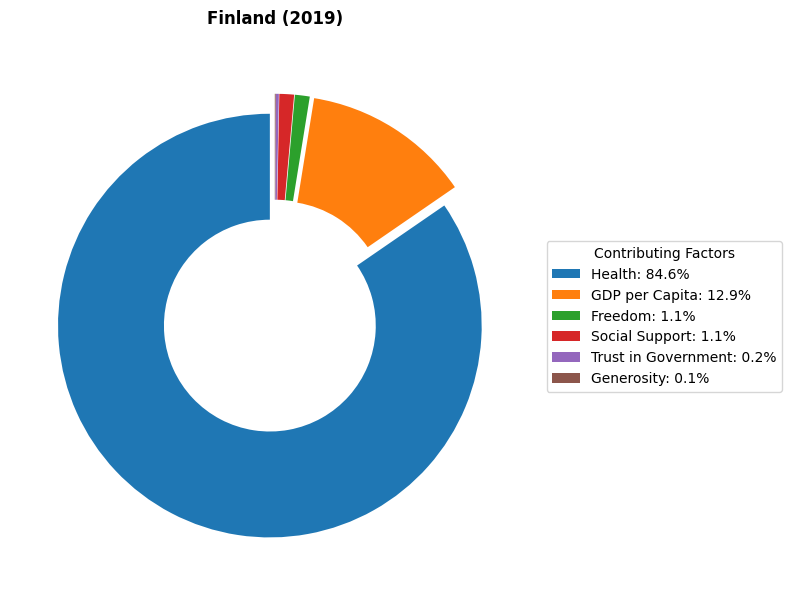

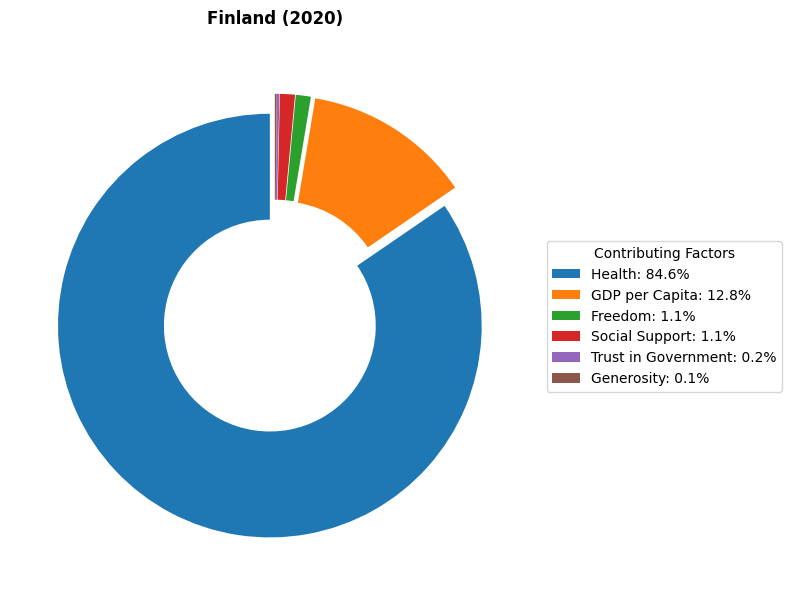

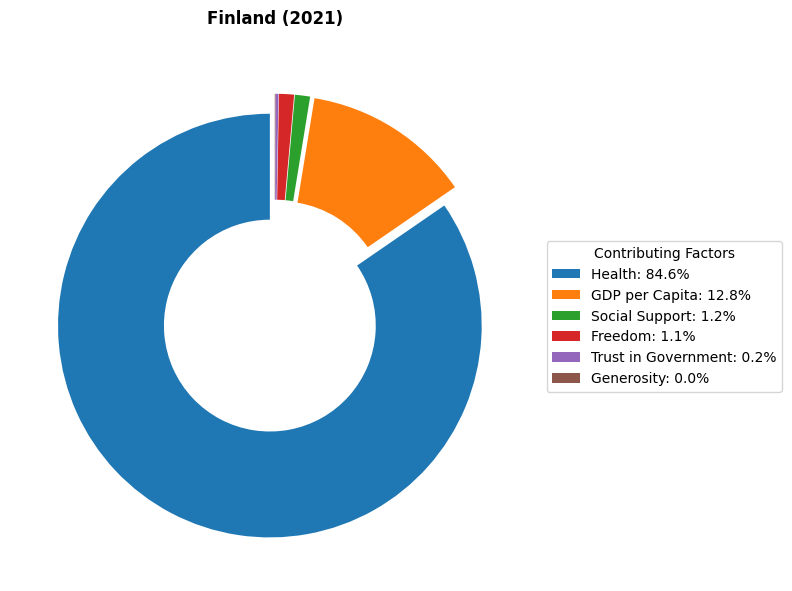

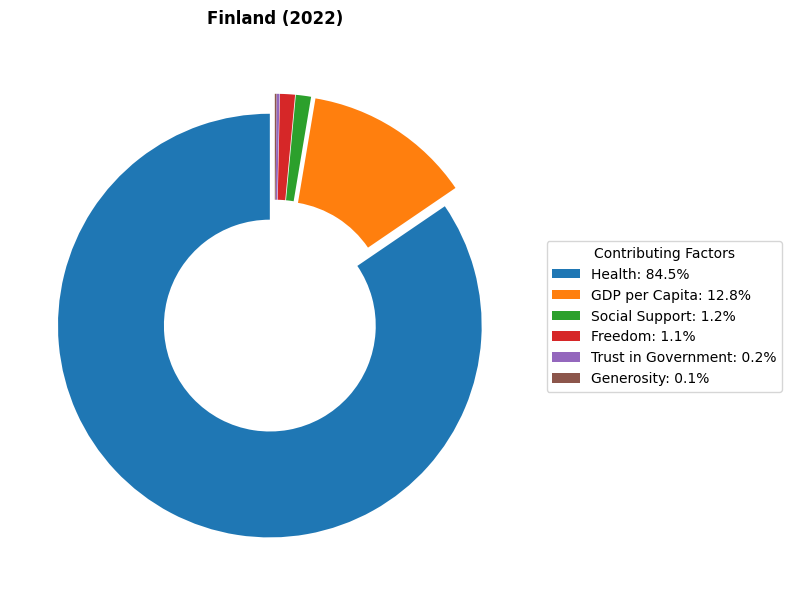

In [27]:
# Finland
for year in years:
    row = df[(df['Country Name'] == 'Finland') & (df['Year'] == year)]
    if not row.empty:
        plot_pie_chart(row.iloc[0], f'Finland ({year})')

<h4>World Average</h4>

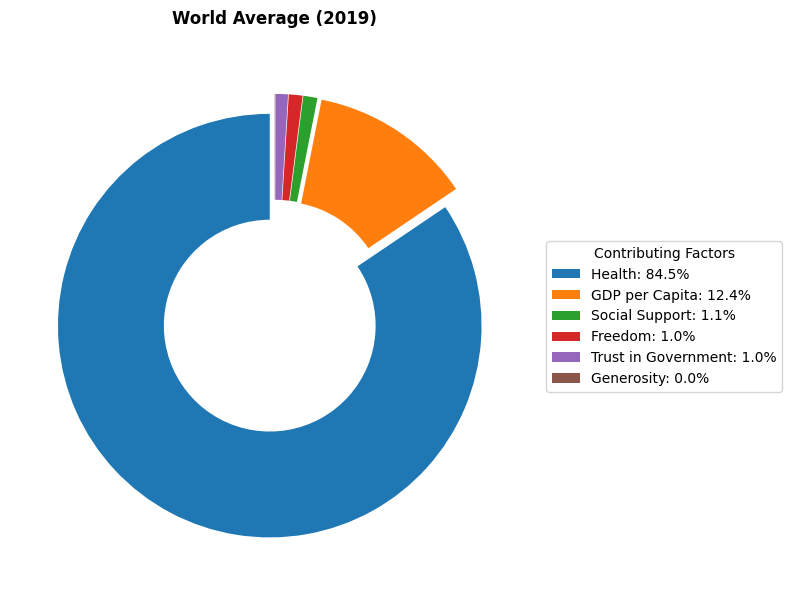

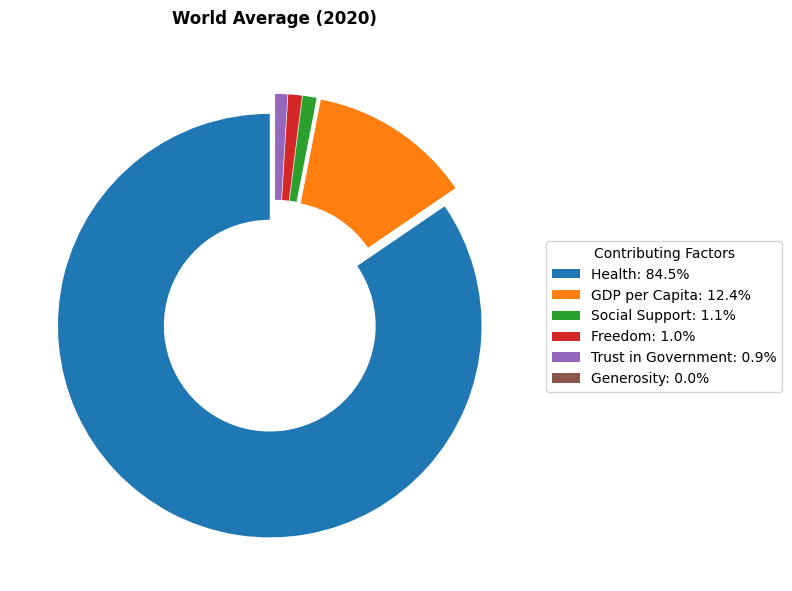

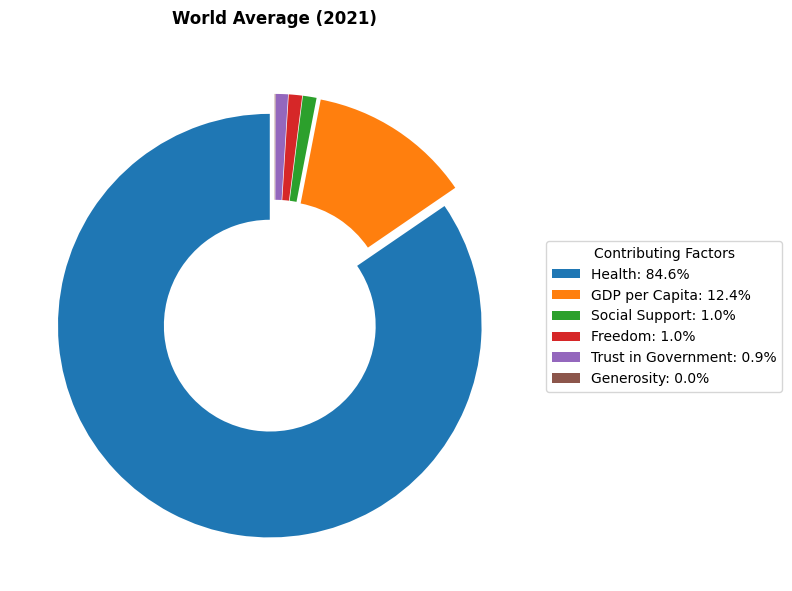

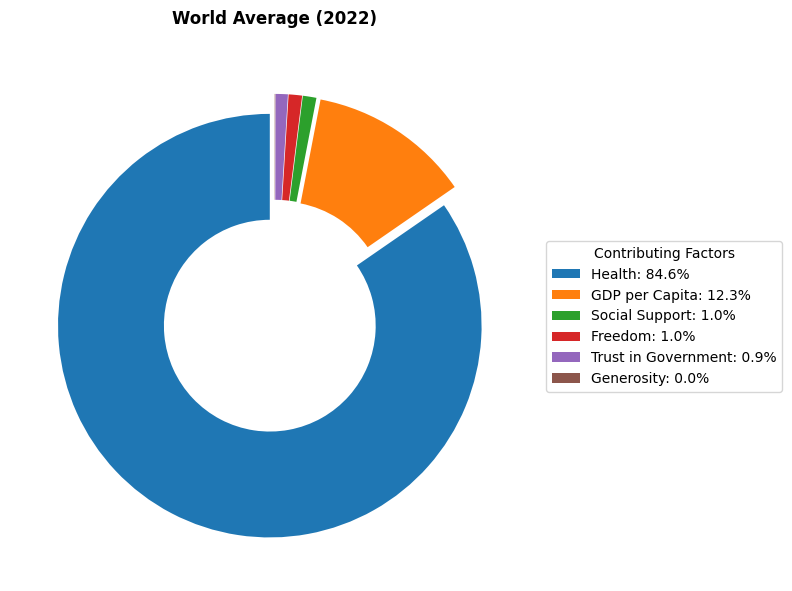

In [28]:
# World Average
world_group = df.groupby('Year')[contrib_cols_old].mean().reset_index()
for year in years:
    row = world_group[world_group['Year'] == year]
    if not row.empty:
        plot_pie_chart(row.iloc[0], f'World Average ({year})')
